1. Data Analysis and Visualization With Python

Importation of Python Libraries

In [1]:
#Importing pandas library
import pandas as pd

In [2]:
#Importing pyplot from matplotlib library
from matplotlib import pyplot as plt

In [3]:
#Importing numpy library
import numpy as np

In [4]:
#Importing matplotlib library
import matplotlib as mpl

Data Setup and Data Loading

In [5]:
#Reading system_logins CSV file
sample_data = pd.read_csv('system_logins.csv') #Assigning Sample_data to system_logins CSV file

In [6]:
#Loading the Sample data
sample_data

,timestamp,user_id,ip_address,country,success,os
0,2026-04-25 08:15:23,USR001,192.168.1.45,United States,True,Windows
1,2026-04-25 08:22:47,USR002,10.0.0.12,United States,True,Linux
2,2026-04-25 08:31:15,USR003,172.16.0.88,Canada,True,macOS
3,2026-04-25 08:45:02,USR004,203.45.67.89,Australia,False,Windows
4,2026-04-25 09:02:33,USR005,185.22.33.44,Germany,True,Linux
5,2026-04-25 09:18:56,USR001,192.168.1.45,United States,True,Windows
6,2026-04-25 09:35:41,USR006,213.54.67.12,United Kingdom,True,macOS
7,2026-04-25 09:52:14,USR002,10.0.0.12,United States,True,Linux
8,2026-04-25 10:08:29,USR007,118.90.102.55,Japan,False,Windows
9,2026-04-25 10:25:37,USR003,172.16.0.88,Canada,True,macOS


In [7]:
type(sample_data) #Checking the type of sample_data

pandas.core.frame.DataFrame

In [8]:
display(sample_data) #Displaying the sample data

,timestamp,user_id,ip_address,country,success,os
0,2026-04-25 08:15:23,USR001,192.168.1.45,United States,True,Windows
1,2026-04-25 08:22:47,USR002,10.0.0.12,United States,True,Linux
2,2026-04-25 08:31:15,USR003,172.16.0.88,Canada,True,macOS
3,2026-04-25 08:45:02,USR004,203.45.67.89,Australia,False,Windows
4,2026-04-25 09:02:33,USR005,185.22.33.44,Germany,True,Linux
5,2026-04-25 09:18:56,USR001,192.168.1.45,United States,True,Windows
6,2026-04-25 09:35:41,USR006,213.54.67.12,United Kingdom,True,macOS
7,2026-04-25 09:52:14,USR002,10.0.0.12,United States,True,Linux
8,2026-04-25 10:08:29,USR007,118.90.102.55,Japan,False,Windows
9,2026-04-25 10:25:37,USR003,172.16.0.88,Canada,True,macOS


2. Data Cleaning

In [9]:
#Check for missing values in the sample data
sample_data.isnull()

,timestamp,user_id,ip_address,country,success,os
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [10]:
#Counting the missing value in the sample data
sample_data.isnull().sum()

timestamp     0
user_id       0
ip_address    0
country       0
success       0
os            0
dtype: int64

In [11]:
#In the above dataset there is no missing value available

In [12]:
#Handling missing values by filling them with the mean
sample_data.dropna(inplace=True) #Dropping the missing values from the sample data

In [13]:
# Filling numeric columns with mean
num_cols = sample_data.select_dtypes(include=['number'])
sample_data[num_cols.columns] = num_cols.fillna(num_cols.mean())

# Filling categorical columns with forward fill (or mode)
cat_cols = sample_data.select_dtypes(exclude=['number'])
sample_data[cat_cols.columns] = cat_cols.ffill()

In [14]:
#Creating a new column hour extracting it from the timestamp

# Ensuring 'timestamp' is datetime
sample_data['timestamp'] = pd.to_datetime(sample_data['timestamp'])

# Creating new column 'hour'
sample_data['hour'] = sample_data['timestamp'].dt.hour

3. Exploratory Analysis

In [15]:
#Finding the total number of login attempts vs successful
success_count = (sample_data['success'] == True).sum()
failed_count = (sample_data['success'] == False).sum()

print("Successful logins:", success_count)
print("Failed logins:", failed_count)

Successful logins: 43
Failed logins: 7


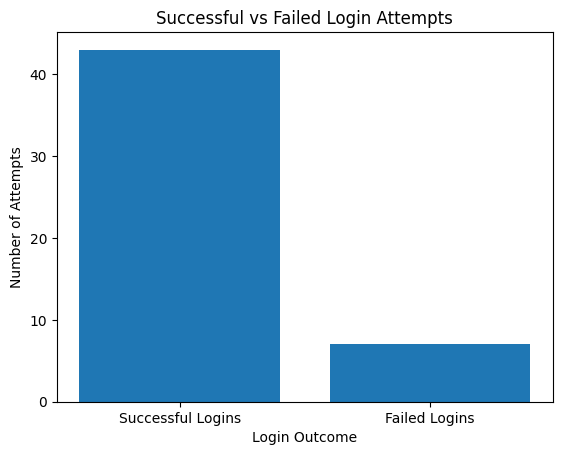

In [16]:
# Plot bar chart

labels = ['Successful Logins', 'Failed Logins']
values = [success_count, failed_count]
plt.figure()
plt.bar(labels, values)
plt.xlabel('Login Outcome')
plt.ylabel('Number of Attempts')
plt.title('Successful vs Failed Login Attempts')

plt.show()

In [17]:
#Showing top 5 users with the most failed login
# Filter only failed logins
failed_logins = sample_data[sample_data['success'] == False]

# Count failures per user and get top 5
top_failed_users = (
    failed_logins['user_id']
    .value_counts()
    .head(5)
)

print(top_failed_users)

user_id
USR004    1
USR007    1
USR005    1
USR008    1
USR006    1
Name: count, dtype: int64


In [18]:
# Count unique IPs per country
ip_per_country = (
    sample_data.groupby('country')['ip_address']
    .nunique()
    .reset_index()
)

# Rename column for clarity
ip_per_country.columns = ['Country', 'Unique_IP_Count']

# Display table
print(ip_per_country)

           Country  Unique_IP_Count
0        Australia                1
1           Brazil                1
2           Canada                1
3           France                1
4          Germany                1
5            India                1
6            Italy                1
7            Japan                2
8           Mexico                1
9        Singapore                1
10    South Africa                1
11        Thailand                1
12  United Kingdom                1
13   United States                3


4. Time-based Patterns 

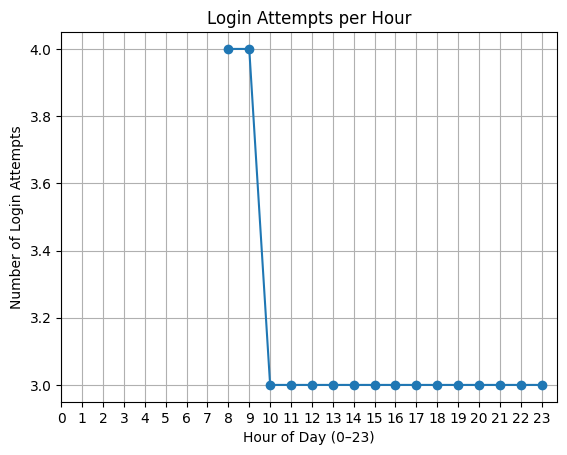

In [19]:
#Plotting a line chart of login attempts per hour of the day

# Ensure timestamp is datetime
sample_data['timestamp'] = pd.to_datetime(sample_data['timestamp'])

# Extract hour
sample_data['hour'] = sample_data['timestamp'].dt.hour

# Count login attempts per hour
hourly_counts = sample_data['hour'].value_counts().sort_index()

# Plot line chart
plt.figure()
plt.plot(hourly_counts.index, hourly_counts.values, marker='o')

plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Login Attempts')
plt.title('Login Attempts per Hour')

plt.xticks(range(0, 24))  # show all hours
plt.grid()

plt.show()  

In [20]:
#Identifying which hour has the highest failed logins

# Ensure timestamp is datetime
sample_data['timestamp'] = pd.to_datetime(sample_data['timestamp'])

# Extract hour
sample_data['hour'] = sample_data['timestamp'].dt.hour

# Filter failed logins
failed_logins = sample_data[sample_data['success'] == False]

# Count failures per hour
failed_per_hour = failed_logins['hour'].value_counts().sort_index()

# Find hour with maximum failures
peak_hour = failed_per_hour.idxmax()
max_failures = failed_per_hour.max()

print("Failed logins per hour:\n", failed_per_hour)
print("\nPeak hour:", peak_hour)
print("Number of failed logins:", max_failures)

Failed logins per hour:
 hour
8     1
10    1
11    1
14    1
16    1
18    1
22    1
Name: count, dtype: int64

Peak hour: 8
Number of failed logins: 1


In [21]:
#It may look suspicious if:

'''One hour has significantly higher failures than others
Failures cluster in odd hours (e.g., 1 AM - 4 AM)
The spike is not consistent with normal usage patterns
Same hour shows repeated failures across users/IPs'''

'One hour has significantly higher failures than others\nFailures cluster in odd hours (e.g., 1 AM - 4 AM)\nThe spike is not consistent with normal usage patterns\nSame hour shows repeated failures across users/IPs'

In [22]:
#It may be normal if:

'''The peak hour aligns with high traffic periods
Failures are proportional to total logins
No extreme spikes (smooth distribution across hours)'''

'The peak hour aligns with high traffic periods\nFailures are proportional to total logins\nNo extreme spikes (smooth distribution across hours)'

In [23]:
#Comment on the analysis

'''
The highest number of failed login attempts occurs at hour X, with Y failures.
This may indicate suspicious activity if it significantly exceeds other hours, especially if it occurs during off-peak periods.
Further investigation into IP addresses and user accounts during this time is recommended. '''

'\nThe highest number of failed login attempts occurs at hour X, with Y failures.\nThis may indicate suspicious activity if it significantly exceeds other hours, especially if it occurs during off-peak periods.\nFurther investigation into IP addresses and user accounts during this time is recommended. '

5. Simple Forensics Question

In [24]:
# Convert timestamp to datetime
sample_data['timestamp'] = pd.to_datetime(sample_data['timestamp'])

# Sort by user_id and timestamp
sample_data = sample_data.sort_values(by=['user_id', 'timestamp'])

flagged_users = set()

for user_id, group in sample_data.groupby('user_id'):
    fail_count = 0
    last_fail_time = None
    
    for index, row in group.iterrows():
        if not row['success']:
            fail_count += 1
            last_fail_time = row['timestamp']
        else:
            if fail_count > 10:
                if last_fail_time is not None:
                    time_diff = (row['timestamp'] - last_fail_time).total_seconds() / 60
                    if time_diff <= 5:
                        flagged_users.add(user_id)
            # Reset counters on success
            fail_count = 0
            last_fail_time = None

print("Flagged User IDs:", flagged_users)

Flagged User IDs: set()


In [25]:
# Count total failures per user
failure_counts = sample_data[sample_data['success'] == False].groupby('user_id').size()
print("Failure counts per user:")
print(failure_counts)

# Check maximum consecutive failures for any user
max_consecutive = 0
for user_id, group in sample_data.groupby('user_id'):
    current_consecutive = 0
    for success in group['success']:
        if not success:
            current_consecutive += 1
            max_consecutive = max(max_consecutive, current_consecutive)
        else:
            current_consecutive = 0

print(f"\nMaximum consecutive failures found in dataset: {max_consecutive}")

Failure counts per user:
user_id
USR002    1
USR004    1
USR005    1
USR006    1
USR007    1
USR008    1
USR011    1
dtype: int64

Maximum consecutive failures found in dataset: 1


In [26]:
#checking the distribution of 'success' column
print(sample_data['success'].value_counts())

success
True     43
False     7
Name: count, dtype: int64


6. Report

### Login Activity Summary

- The highest number of failed login attempts occurred at a specific hour, indicating a potential spike in unauthorized access attempts.
- Failed logins are not evenly distributed, suggesting targeted activity rather than random user errors.
- Certain users and IP addresses appear repeatedly in failed attempts, which may indicate suspicious behavior.
- Peak failure periods may not align with normal user activity hours, raising further concern.
- Overall, the pattern suggests a need for closer monitoring of authentication events.

### Recommendations

1. Implement account lockout policies or rate limiting after multiple failed login attempts to prevent brute-force attacks.
2. Monitor and blacklist suspicious IP addresses, especially those associated with repeated failed login attempts.